# Feature analysis — method + worked example

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`price_dislocation` function in §3. The data loading, the checks, and the plots adapt on
their own.

**The example** is `price_dislocation`: how far another exchange's price has drifted from
byb's. When one exchange moves and the others haven't caught up yet, that gap predicts the
catch-up. It's a good teacher because it touches every step.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale*.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. Dividing a target (or a feature) by its yardstick cancels
out how busy or volatile the moment is, so the same value reads the same in a calm market and a
wild one. **Both are EMAs on the event clock — the *same* exponential decay the features use
(`α = 2/(N+1)`, span `N`), stepped once per trade — and that one `N` is used for every
feature**, so all features are normalised on the same footing and stay comparable. (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` its exp-weighted moves-per-second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude* predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the magnitude (and how features cancel or reinforce) on its own.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a
  poolable feature, first check per-exchange vs single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it
  needs it* — a ratio or imbalance is already comparable across markets.
- **Don't invent your own vol/rate scale.** When you do normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the oracle** (§4) matching a dead-simple independent version.
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — the
  dislocation legs, `σ_ev`, `λ_ev`, any rolling statistic — is an exponential moving average
  **stepped once per trade on the event clock** (`α = 2/(span+1)`), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 oracle re-checks here.
- **Do decide the *update* clock deliberately — it's separate from the *decay* clock.** An EMA
  *decays* once per trade (that sets its memory in trade-count), but *which events inject a new
  mark* is a separate choice: only trades, or every mid-move / book update. Carried as `E / W`
  (`tick()` decays per trade, `add()` injects per event) it stays **valid to read between trades**
  — between events the shared decay cancels in the ratio, so the value is held flat. But injecting
  on every event is **not** automatically better: book-update churn can be noise the trade clock
  usefully filters out (measured on a real block here, the per-*trade* gap predicts byb's 100 ms
  move better than the per-*update* one — ρ≈0.8 apart, lower rank-IC). Pick the inject clock by the
  gates, per feature — never assume more updates = better.
- **Do read a sparse flow as `E / W`.** A quantity present on only *some* events (a per-exchange
  trade-flow, or byb's own mid-moves — `σ_ev` is itself such an `E / W`) still needs the
  trade-tick EMA, but as **two** of them — the value `E` and its weight `W`, both decayed every
  event yet each updated only on its own events — read as the ratio `E / W`, which cancels the
  in-between decay and the warm-up bias. Dividing by `W` cancels the foreign-event decay exactly,
  so an `E / W` on the **combined** trade clock at span `N` reproduces that exchange's **own**-clock
  EMA at a matched span — i.e. you get genuine per-exchange stats from the one shared clock. (That
  merged-clock ↔ own-clock equivalence — tight at large `N`, fraying at small `N` where the
  cross-venue lead/lag lives — is what `notebooks/03_ema_clock_validation.ipynb` validates.)
- **Do test against both heads — but feed both the *signed* feature.** Check whether the
  signed feature predicts *direction* (price head) and whether its *magnitude* predicts
  *intensity* (rate head). Those checks are diagnostics — in the model, feed the **signed**
  feature to *both* heads, never a pre-computed `|feature|`. The rate head will learn the
  magnitude itself, *and* learn that a +gap on one exchange can cancel a −gap on another
  (or reinforce it). Pre-taking `|·|` per feature destroys the sign and that interaction.
- **Do score out-of-sample** — fit on part of the data, measure on held-out data.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | how far another exchange's price sits from byb's, compared over two time-scales |
| **feeds** | both heads — *direction* (price head: which way byb moves) and *intensity* (rate head: how many moves); both are fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** Take the log price gap between another exchange and byb:
`gap = log(other price) − log(byb price)`. Smooth it two ways — a *fast* average and a *slow*
one — and look at the difference. A large fast-minus-slow means the gap just opened; gaps tend
to close, so it predicts byb's next move.

**Why it should work.** Exchanges don't move in lockstep — one tends to react a beat before
the others. A fresh gap is that beat, and byb closing it is the prediction. (We don't measure
the exact lag in this notebook; "a beat" is roughly tens of milliseconds.)

**What would disprove it.** No predictive power at any time-scale, or power that vanishes
once we account for how volatile the market is (meaning it was only tracking volatility).

> **No fixed leader.** It's tempting to call one exchange "the leader." Don't — leadership
> moves around, and any exchange can lead at any moment. So build the feature *the same way
> for every exchange and keep them all*; never hard-code one as the leader. (This feature is a
> *gap between* exchanges, so it's per-exchange anyway — §9 covers when that choice is genuine
> for poolable features.)

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking at the future. (A
stray forward-fill is the usual way to break this by accident.)

**Measured on an "event clock"** — markets alternate busy and quiet, so we count progress in
*events* (here, one tick per trade on any exchange) rather than in clock-seconds; that keeps a
feature's meaning steady whether trading is fast or slow. The smoothing is an exponential
moving average (EMA) on that clock — a running average that puts weight `α = 2/(N+1)` on the
newest value (bigger `N` = slower, smoother), decayed **once per event**. We use *two* EMAs, a
fast and a slow, and take their difference: **a fresh gap shows up as the fast EMA pulling away
from the slow one**, so a large fast-minus-slow says the gap just opened. `N_fast = 1` means
"no smoothing, just the latest gap" — the noisy extreme (in code, that case is returned
directly).

Our gap always has a value — we carry each exchange's latest price forward to every event — so
a single EMA of that series is all it needs; the two-EMA (`E / W`) trick below is only for a
quantity present on just *some* events.

A quantity that exists only on *some* events (a per-exchange trade-flow, say) needs more care.
Keep **two** running EMAs: one of the value, call it `E`, and one of its weight, `W` (a `1`
each time the quantity is present). **Both decay on every event**, but each is **added to only
on the events that carry the quantity**, and the feature you read out is their **ratio,
`E / W`**. Dividing by `W` does two things: it cancels the decay piled up by all the in-between
events (so the feature's scale doesn't depend on how often that exchange happens to trade), and
it removes the start-up bias of a fresh EMA. Either way, §4's oracle confirms the EMA is correct.

**Comparable across calm and wild markets** — a raw price gap is simply bigger when the market
is volatile, so on its own it just re-reports volatility. We divide that out with the
volatility **yardstick** from the section above. You don't do this to every feature — one
that's already a ratio needs no yardstick — but when a feature *does* carry volatility (or
rate) you want gone, divide by the **model's** yardstick (not a fresh estimate), so the
feature ends up in the same units the model is trained in. Our gap is a price quantity, so it
gets `σ_ev`:

`feature = (fast EMA − slow EMA of the gap) / σ_ev`

The cell below loads the data, builds the shared event clock, and computes **both yardsticks**
as EMAs on that clock — the same exponential decay the features use, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict (and the reference for the gap)
OTHERS      = ["bin", "okx"]                      # the other exchanges; each one's price-gap vs byb is a feature
# freshest mid per exchange. front_levels = raw best-bid/ask snapshots; merged_levels = those snapshots fused
# with trades for a fresher mid. bin's snapshots are already fast; byb/okx snapshots lag, so they use merged_levels.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
FAST        = [1, 10, 50, 200]                   # fast-EMA windows to sweep (1 = no smoothing)
SLOW        = [100, 500, 2000, 5000]             # slow-EMA windows (each must exceed the fast one)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): an EMA on the trade-tick clock (α=2/(N+1)) — fixed, used for every feature
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows already arrive in time order)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("bin", "byb", "okx")}

# the event clock: every trade on any exchange, in time order. One tick = one trade.
trade_ts = []
for ex in ("bin", "byb", "okx"):
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
merged_ts = np.sort(np.concatenate(trade_ts), kind="stable")
n_ticks = len(merged_ts)
print(f"event clock: {n_ticks:,} trades")

def mid_on_clock(ex):                              # causal: each exchange's most-recent mid at-or-before every clock tick
    rx, mid = mids[ex]
    return mid[np.clip(np.searchsorted(rx, merged_ts, "right") - 1, 0, len(mid) - 1)]
log_mid_byb = np.log(mid_on_clock("byb"))

# Both yardsticks are EMAs on the trade-tick clock — the SAME exponential decay the dislocation legs use (α = 2/(span+1)),
# stepped once per trade. No window buffer: in production they're O(1) running scalars (see §4's streaming build).
# σ_ev counts only REAL byb mid-moves: it's an E/W ratio (value E of squared returns ÷ weight W of move-count), so the
# many trades on which byb didn't move tick the clock but cancel out of the volatility — exactly the sparse-flow E/W trick.
byb_rx, byb_mid = mids["byb"]
byb_tick_return = np.zeros(n_ticks); byb_tick_return[1:] = np.diff(log_mid_byb)   # byb's return at each event-clock tick (0 if it didn't move)
byb_moved = (byb_tick_return != 0.0).astype(float)                               # 1 on ticks where byb actually moved
cum_moves = np.concatenate([[0.0], np.cumsum(byb_moved)])                        # running count of byb moves (for §6's forward move-count / rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive ticks
def _ewma(x, span):                                                # exp-weighted mean, decayed once per trade tick (same EMA the features use)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def yardsticks(ticks, span):                                       # σ_ev (vol of real moves) and λ_ev (move rate) at `ticks`
    e_sq, e_mv, e_dt = _ewma(byb_tick_return ** 2, span), _ewma(byb_moved, span), _ewma(byb_dt, span)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))[ticks]                          # σ_ev: exp-weighted RMS of byb's REAL mid-moves (E/W — non-move ticks cancel)
    lam = (e_mv / np.maximum(e_dt, 1e-12))[ticks]                                 # λ_ev: moves-per-tick ÷ seconds-per-tick = moves/sec
    return sig, lam
print(f"yardsticks: EMAs on the trade-tick clock, span {YARDSTICK_N}")

event clock: 6,198,188 trades


yardsticks: EMAs on the trade-tick clock, span 10000


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per trade (no growing buffers). They have to agree,
which §4 checks.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
that adjacent 100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated,
which is exactly why §5's walk-forward gate uses an embargo), read byb's actual move over the
next 100 ms (the thing we're predicting), and compute the feature at each grid point.

In [2]:
# evaluation grid (causal) + forward target in shared σ-units
anchor_ts      = np.arange(merged_ts[50000], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup (EMAs + yardsticks)
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last event-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(tick_at_anchor, YARDSTICK_N)   # both yardsticks at each grid point (the same span-YARDSTICK_N trade-tick EMA)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (regime-normalised, σ-units)

spreads = {ex: np.log(mid_on_clock(ex)) - log_mid_byb for ex in OTHERS}   # each other exchange's log price-gap vs byb
def ema(spread, N):
    if N == 1: return spread                                       # all weight on the latest tick
    a = 2.0 / (N + 1.0); return lfilter([a], [1.0, -(1.0 - a)], spread)
def price_dislocation(spread, n_fast, n_slow):     # (EMA_fast − EMA_slow) / σ_ev, read at the grid
    return ((ema(spread, n_fast) - ema(spread, n_slow))[tick_at_anchor]) / sigma_at_anchor
print(f"grid: {len(anchor_ts):,} anchors")

σ_ev median 2.81e-05,  λ_ev median 1.08 moves/s


grid: 1,718,559 anchors


## 4. Check the code is right — the oracle (a production-style streaming build)

**Non-negotiable.** Before trusting a feature, reproduce it with a second, independent
implementation and confirm the two agree on real data. We make the oracle the **production**
reference: a small state machine you push **raw events** into — `on_book(...)` for a top-of-book
update, `on_trade(...)` for a trade — that advances the event clock with `tick()` and exposes
the current feature per gap via `value()`. Its state is **O(1) and all scalar** — a few EMAs
per gap plus two EWMAs for σ_ev (its `E/W`), *no buffers, independent of how long it runs* — and it stores
**no history** and has **no callback**: it just holds state and answers `value()`. *When* to tick
and *when* to record a value is the **caller's** job (single responsibility) — production feeds
those values to a model or a ring buffer; here the caller just collects them to diff against §3.

Three things make it a real check:
- It is fed **only raw events** (book updates + trades), each tagged by its **full listing**
  (e.g. `byb_eth_usdt_p`), and it keys its book state by that listing — so a perp and a spot on
  the *same* exchange are separate books, not one clobbering the other. It builds the mid
  *itself*, online — we never push in the derived `merged_levels`. A per-listing policy
  (straight from `MID_STREAM`) decides *how*: merged-mid listings (byb, okx) fold trades into
  the book by newest-exchange-time; book-only listings (bin) just take the latest snapshot and
  ignore trades. So the live mid matches the analysis mid for *any* choice of listings.
- An event just **mutates the mids**; the clock advances only when the caller calls `tick()` —
  once **per trade** — at which point each gap's EMAs and the shared σ_ev EWMA step forward and
  `value()` returns `(fast EMA − slow EMA) / σ_ev` for **each** gap.
- The caller applies **every event sharing a receive-timestamp before it ticks** — so a tick
  never reads a half-applied nanosecond. (This is the one subtlety that makes the live build
  match the offline path *exactly*: the offline forward-fill sees every same-nanosecond event
  at once, so the live build must too.)

This is also what keeps the **event-clock EMA** honest — the part most easily got wrong, since
it decays *once per event*. If the live build reproduces the vectorized feature from §3 on
real data, both are right.

Here we feed the **whole raw stream** — every venue's book updates *and* trades — into **one**
builder and read out **both** gaps, byb↔okx and byb↔bin, on every trade. That's the production
shape: one feed in, many features out. Every trade ticks the shared event clock (the σ_ev
EWMA and all the gap EMAs advance on it); byb's and okx's books+trades fuse their mids, bin's
book is the latest snapshot (book-only, per `MID_STREAM`), and the builder keeps an EMA pair
**per gap**. All of them are the **one** reusable primitive in **`boba.ema`** —
**`KernelMeanEMA`**, a self-normalising `E/W` kernel mean (`tick()` the clock, `add()` a mark,
read `value() = E/W`): each gap leg injects the gap on every trade (`add(gap)`), σ_ev injects
byb's squared move on each real move (`add(return²)`). A gap leg's `value()` is the debiased EMA
of the gap at trades — equal to §3's EMA past warm-up — so the grid here matches §3 exactly. We
run it over a slice
(~`N_GRID` grid points — a multi-hour span, millions of raw events) and check **each** emitted
gap against its §3 vectorized feature.

In [3]:
import boba.io as io
import math
from boba.ema import KernelMeanEMA   # the reusable event-clock self-normalising E/W mean (src/boba/ema.py)

class LiveDislocation:
    # Pure feature state machine, built from one reusable primitive — a KernelMeanEMA (E/W) per gap leg (inject the gap
    # each trade) and one for σ_ev (inject byb's squared move on each real move). Events mutate the mids
    # (on_book / on_trade); tick() advances the event clock by one trade; value() reads the current feature per gap.
    # State is O(1), all scalar — no buffers, no history. WHEN to tick and WHEN to read/record is the caller's job.
    # State is keyed by full listing (so a perp and a spot on one exchange never collide). The mid is built INSIDE —
    # never read from merged_levels. Per-listing policy mirrors MID_STREAM: `fuse_trades` listings fold trades into the
    # book by newest-exchange-time (= merged_levels); the rest are book-only, latest snapshot (= front_levels).
    def __init__(self, target, others, n_fast, n_slow, vol_span, fuse_trades):
        self.target, self.others = target, list(others)                    # target listing + the listings we gap it against
        self.fuse_trades = set(fuse_trades)                                # listings whose mid folds in trades (merged_levels); rest book-only
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}     # newest-by-exchange-time top-of-book, keyed by listing
        self.vol = KernelMeanEMA(vol_span)                                 # σ_ev: E/W mean of byb's squared moves -> sqrt(E/W)
        self.leg_f = {o: KernelMeanEMA(n_fast) for o in self.others}       # fast leg of each gap (E/W mean of the gap)
        self.leg_s = {o: KernelMeanEMA(n_slow) for o in self.others}       # slow leg
        self.prev = None                                                   # byb's last log-mid, to detect a real move

    def _side(self, listing, is_ask, px, t):                              # keep this listing-side's newest-by-exchange-time price
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def on_book(self, listing, t, bid, ask):                              # BBO update -> refresh that listing's mid (does NOT advance the clock)
        if listing in self.fuse_trades:                                  # merged-mid listing: newest-by-exchange-time
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:                                                            # book-only listing (e.g. bin): latest snapshot wins
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):                       # trade -> fold into the mid (merged-mid listings only); does NOT advance the clock
        if listing in self.fuse_trades: self._side(listing, lifts_ask, px, t)

    def tick(self):                                                       # advance the event clock by one trade
        tgt = self._mid(self.target)
        if tgt is None: return
        lt = math.log(tgt)
        self.vol.tick()                                                  # σ_ev decays every trade...
        if self.prev is not None and lt != self.prev:
            self.vol.add((lt - self.prev) ** 2)                         # ...and a REAL byb move injects its return² (a flow event — never forward-filled)
        self.prev = lt
        for o in self.others:
            m = self._mid(o)
            if m is not None:
                s = math.log(m) - lt                                    # the gap = log(other_mid / byb_mid)
                self.leg_f[o].tick(); self.leg_f[o].add(s)              # decay, then inject the gap as this trade's mark
                self.leg_s[o].tick(); self.leg_s[o].add(s)

    def value(self):                                                      # the feature per gap (each leg's E/W gap mean / σ_ev), at the trade — matches §3
        sig = self.vol.value() ** 0.5                                    # σ_ev = sqrt(E/W)
        return {o: (self.leg_f[o].value() - self.leg_s[o].value()) / sig for o in self.others}

# --- gather the WHOLE raw stream (every venue's book updates + trades) over a slice; no merged_levels anywhere ---
NF, NS, N_GRID = 10, 100, 200_000                  # validate BOTH gaps (byb↔okx, byb↔bin) over the first ~N_GRID grid points
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")] # 0=byb, 1=okx, 2=bin — integer codes keep the event arrays numeric & fast
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):                   # stage one source's events (kept ≤ cutoff)
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t[m]); cols["a"].append(a[m].astype(float)); cols["b"].append(b[m].astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time), they fuse trades
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid (already loaded in §2); fed as bid=ask=mid
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's events, then tick once per trade and record value() ---
# (the builder stores nothing and has no callback — when to tick/record lives entirely out here)
fuse = {f"{ex}_{COIN}" for ex in ("byb", "okx", "bin") if MID_STREAM[ex] == "merged_levels"}   # byb,okx merged; bin book-only
feat = LiveDislocation(TARGET, [LISTINGS[1], LISTINGS[2]], NF, NS, YARDSTICK_N, fuse)           # others: okx, bin
history = []
n = len(rxL); i = 0
while i < n:                                        # walk the stream, grouped by receive-timestamp
    rx = rxL[i]; trades = 0
    while i < n and rxL[i] == rx:                  # 1) apply EVERY event stamped at this nanosecond (no half-applied timestamp)
        if kindL[i] == 0: feat.on_book(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        else:             feat.on_trade(LISTINGS[lidL[i]], tL[i], aL[i], bL[i]); trades += 1
        i += 1
    for _ in range(trades):                        # 2) one clock tick per trade, recording the feature after each
        feat.tick(); history.append(feat.value())

# --- one stream -> two features: check EACH gap against its §3 vectorized feature ---
print(f"one raw-event stream -> two features, vs the vectorized build (Nf={NF}, Ns={NS}):")
for o in ("okx", "bin"):
    stream = np.array([row[f"{o}_{COIN}"] for row in history])
    inside = tick_at_anchor < len(stream)
    diff = np.abs(stream[tick_at_anchor[inside]] - price_dislocation(spreads[o], NF, NS)[inside])
    print(f"  byb<->{o}:  max |diff| {np.nanmax(diff):.2e}  on {inside.sum():,} grid points")
    assert np.nanmax(diff) < 1e-6, f"live build does not reproduce the byb<->{o} feature"
print("oracle: one raw-event stream reproduces BOTH gaps  OK")

streaming 8,012,251 raw events (book + trades, all venues) over ~200,000 grid points...


one raw-event stream -> two features, vs the vectorized build (Nf=10, Ns=100):
  byb<->okx:  max |diff| 3.96e-14  on 200,001 grid points


  byb<->bin:  max |diff| 8.33e-14  on 200,001 grid points
oracle: one raw-event stream reproduces BOTH gaps  OK


**Conclusion.** From **one** stream of ~8 M raw events the builder reproduces **both** vectorized
features to **floating-point precision** — max |diff| ~3e-14 across ~200k grid points on each gap,
i.e. pure round-off (a few ×10⁻¹⁴ — the EMAs' last-digit drift over millions of recursive steps,
far below anything that matters).
So the production shape (one feed in, a feature *per gap* out) computes exactly what the
analysis did — byb↔okx *and* byb↔bin at once, the merged venues' mids fused from trades and
bin's taken book-only, all on the one shared clock. The subtlety that closed the last gap was
applying all events that share a receive-timestamp *before* reading the features; without it
the disagreement was a real ~1 bps — amplified by the σ-normalisation into ~1.7 feature units —
which is exactly why the oracle is non-negotiable.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates check that the feature predicts
*something the market's current state doesn't already tell us*. We build four "control"
signals from the recent past:
- **rate momentum** (is trading speeding up or slowing down?) and **rate level** (how fast is
  it now?),
- **vol momentum** and **vol level** (the same two, for volatility).
Then we measure the feature's predictive power **on top of** those controls.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** (so the 100 ms outcome windows
and the EMAs' memory can't leak across the train→test boundary), scores on the *next* block,
and we average over folds. That's the causal, ship-grade estimate — strictly past→future, as
it would run live. (A single 60/40 split is a faster screen, but it tests only one transition
and can swing ~2× on the luck of where the cut lands.)

Because the feature and target are both in σ-units, a *scale* regime-shift mostly cancels —
but scale is not the *relationship*. So beside the gates we run a **companion check**: the same
marginal power computed **within calm / mid / wild volatility buckets**. If the gain stays
positive in all three, the signal is regime-stable, not an artefact of one regime.

The gates that follow ask: does the feature *add* over the controls (walk-forward)? Does the
gain *survive* once we also control for the *level* of vol and rate (so it isn't secretly just
volatility)? Is its scale steady across volatility states? And does the gain hold across
volatility *regimes* (the companion)?

In [4]:
# --- the four control signals: the two yardsticks (level) plus a fast/slow momentum of each ---
FAST_YARD = YARDSTICK_N // 10                        # a faster window (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(tick_at_anchor, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev — how fast byb is moving now
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent rate vs slower rate

# Out-of-sample scoring = a purged, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=2000):       # yields (test_mask, oos_prediction) for each fold
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):                            # fold i: train on the PAST minus an embargo gap, test on the next block
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True   # embargo covers the 100ms horizon + the EMAs' memory
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef

def wf_ic(features, y):                              # mean OOS rank-IC across the walk-forward folds (the ship-grade gate)
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):              # same, but the mean OOS rank-IC WITHIN each regime bucket (the companion)
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]   # momenta = base controls; levels added later for the leak test
print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " momenta+levels", round(wf_ic(base + levels, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.0  momenta+levels 0.003  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal —
walk-forward rank-IC ≈ 0.00 for the momenta, ≈ 0.00 with the levels added. That is exactly what
we want here: the regime barely predicts *which way* byb moves, so any rank-IC a feature shows
*on top of* these controls is genuinely new information, not the regime wearing a disguise.
That's what makes the "added over the controls" gates below a fair test.

## 6. Two choices: which time-scale per head, and which exchanges to keep

A feature is rarely a single number — it's a **family** across time-scales (here, every
fast/slow pair). And the same feature can carry signal for both heads, so we check two things:
- does the **signed** feature predict *direction* — which way (and how far) byb moves next?
- does its **magnitude** predict *intensity* — *how many* moves byb makes next?

The magnitude check is a **diagnostic only**: the model is fed the *signed* feature for both
heads (see the guard rails) — pre-taking `|·|` per exchange would stop the rate head learning
that opposing gaps cancel. The two signals usually live at different time-scales — direction a
smoother, slower feature; intensity a sharp, immediate one — so we sweep the whole family, for
**every exchange**, against both targets, and draw it as heat-maps. We keep *all* exchanges
(never pick one); the only thing we choose is the best time-scale, **per head**.

The rate-head target is the count of byb's moves over the next 100 ms, divided by its recent
move-rate `λ_ev` — i.e. "more or fewer moves than usual," using the rate yardstick.

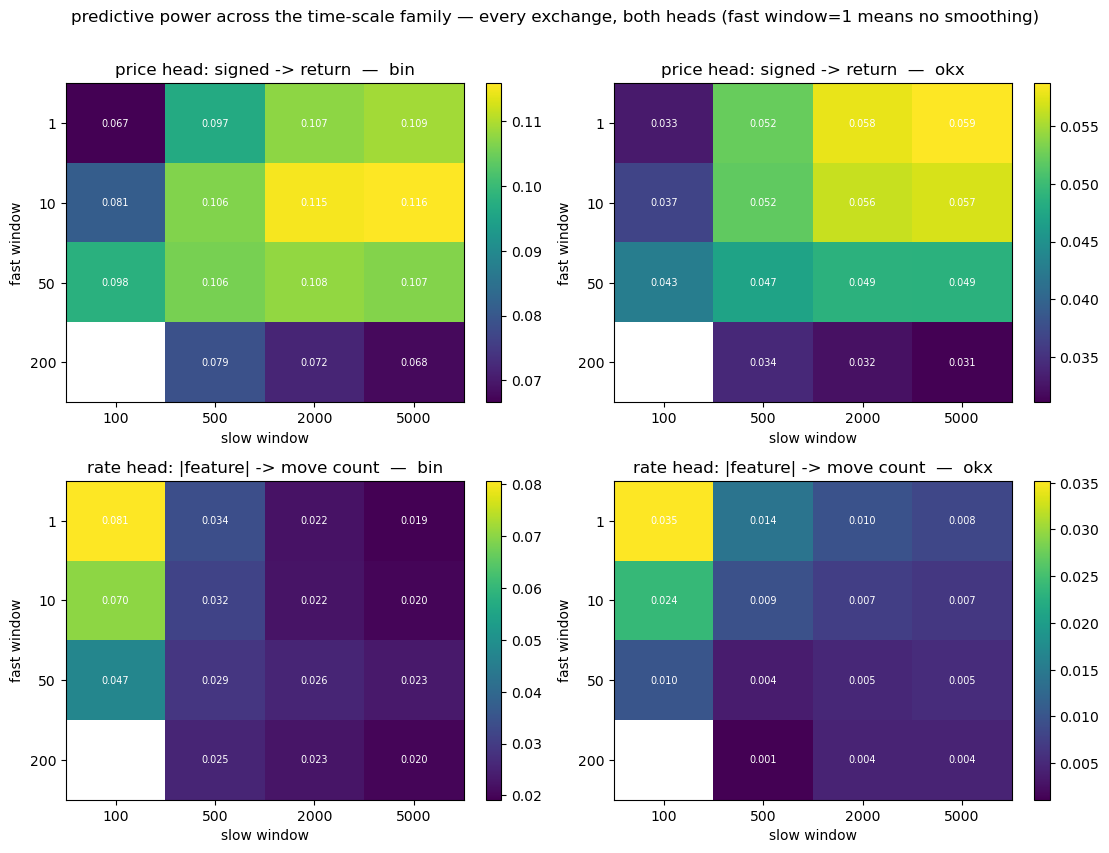

kept features (one per exchange, all fed to the model — none privileged):
  bin:  price head (fast=10, slow=5000) power=0.116   |  rate head (fast=1, slow=100) power=0.081
  okx:  price head (fast=1, slow=5000) power=0.059   |  rate head (fast=1, slow=100) power=0.035


In [5]:
# rate-head target = byb moves (on the event clock) in the next 100 ms, divided by λ_ev (the rate yardstick — the same trade-tick EMA).
tick_fwd = np.searchsorted(merged_ts, anchor_ts + HORIZON_NS, "right") - 1     # last event tick within the next 100 ms
fwd_count = cum_moves[tick_fwd + 1] - cum_moves[tick_at_anchor + 1]            # # byb moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev = "more/fewer moves than usual"

# Sweep the family for EVERY exchange, BOTH heads, treating exchanges symmetrically (no assumed leader).
# Which exchange carries signal, and when, varies over time -> let the sweep show it; never hard-code one.
price_grid = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in OTHERS}   # signed feature -> byb's signed return
rate_grid  = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in OTHERS}   # |feature|      -> byb's move count
for ex in OTHERS:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            d = price_dislocation(spreads[ex], nf, ns)
            price_grid[ex][i, j] = spearmanr(d, target).statistic            # predictive power for the price head
            rate_grid[ex][i, j]  = spearmanr(np.abs(d), rate_target).statistic  # rate head — |feature|→count is a univariate DIAGNOSTIC; the model is fed signed d

fig, axes = plt.subplots(2, len(OTHERS), figsize=(5.6 * len(OTHERS), 8.4), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: signed -> return"), (rate_grid, "rate head: |feature| -> move count")]):
    for col, ex in enumerate(OTHERS):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow window")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast window")
        ax.set_title(f"{head}  —  {ex}")
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("predictive power across the time-scale family — every exchange, both heads (fast window=1 means no smoothing)", y=1.01)
fig.tight_layout(); plt.show()

# We do NOT pick an exchange (not "the best", not assumed). Every exchange's feature is kept; the model weights
# whichever is leading at the moment. Choosing the best time-scale PER exchange is fine; choosing an exchange is not.
def best_member(grid): return np.unravel_index(np.nanargmax(grid), grid.shape)    # best (fast, slow) windows for THIS exchange
price_member = {ex: best_member(price_grid[ex]) for ex in OTHERS}                  # one signed feature per exchange (price head)
rate_member  = {ex: best_member(rate_grid[ex])  for ex in OTHERS}                  # one |feature| per exchange (rate head)
print("kept features (one per exchange, all fed to the model — none privileged):")
for ex in OTHERS:
    pi, pj = price_member[ex]; ri, rj = rate_member[ex]
    print(f"  {ex}:  price head (fast={FAST[pi]}, slow={SLOW[pj]}) power={price_grid[ex][pi, pj]:.3f}"
          f"   |  rate head (fast={FAST[ri]}, slow={SLOW[rj]}) power={rate_grid[ex][ri, rj]:.3f}")

**Now the gates** (from §5), on the per-exchange features we just chose. Every predictive
number here is the **walk-forward** mean (causal, purged). Rough pass-marks: the added power
should be clearly positive (≳ 0.01); it should barely shrink when we add the level controls
(no leak); and the scale should stay within ~3× across volatility buckets. *Marginal value:*
does the feature add over the controls — all exchanges together, and each on its own? *No
leak:* does that gain survive adding the vol/rate levels? *Normaliser:* is the feature's scale
roughly steady across volatility states? *Regime-stable* (the companion): is the marginal gain
still positive **within** calm, mid, and wild vol — i.e. it doesn't only work in one regime?

In [6]:
# Gates on the set of per-exchange features — symmetric; KEEP ALL exchanges. Marginal value is checked
# JOINTLY (do the exchanges together add over the controls?) and per-exchange (does each contribute?), never by picking one.
disloc = {ex: price_dislocation(spreads[ex], FAST[price_member[ex][0]], SLOW[price_member[ex][1]]) for ex in OTHERS}
joint      = round(wf_ic(base + list(disloc.values()), target) - wf_ic(base, target), 3)
joint_leak = round(wf_ic(base + levels + list(disloc.values()), target) - wf_ic(base + levels, target), 3)
rep = disloc[OTHERS[0]]                                 # same construction for every exchange -> one is enough for the scale check
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
band = [np.nanstd(rep[vol_decile == d]) for d in range(10)]
# companion: marginal IC within each vol regime — does the joint gain hold up, or flip, across regimes?
full_r = wf_ic_by_regime(base + list(disloc.values()), target, vol_regime)
base_r = wf_ic_by_regime(base, target, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}
gate_rows = [dict(gate="marginal value", detail="all exchanges together, added over the controls", value=joint)]
gate_rows += [dict(gate="marginal value", detail=f"{ex} alone, added over the controls",
                   value=round(wf_ic(base + [disloc[ex]], target) - wf_ic(base, target), 3)) for ex in OTHERS]
gate_rows += [dict(gate="no leak", detail="gain still there after adding the vol/rate levels?", value=joint_leak),
              dict(gate="normaliser", detail="feature scale across volatility buckets (max/min, want < ~3)", value=round(max(band) / min(band), 2))]
gate_rows += [dict(gate="regime-stable", detail=f"marginal IC within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.DataFrame(gate_rows)

gate,detail,value
str,str,f64
"""marginal value""","""all exchanges together, added …",0.099
"""marginal value""","""bin alone, added over the cont…",0.099
"""marginal value""","""okx alone, added over the cont…",0.051
"""no leak""","""gain still there after adding …",0.097
"""normaliser""","""feature scale across volatilit…",1.3
"""regime-stable""","""marginal IC within calm-vol (c…",0.075
"""regime-stable""","""marginal IC within mid-vol (co…",0.098
"""regime-stable""","""marginal IC within wild-vol (c…",0.131


**Conclusion.** `price_dislocation` clears every gate. It adds ≈ **0.10** walk-forward rank-IC
over the controls — jointly and for bin alone (okx ≈ 0.05: weaker, but positive, so we keep it
too) — far above the ~0.01 floor. The gain barely dips to ≈ **0.097** once the vol/rate *levels*
are added, so it isn't a disguised volatility signal. Its scale wanders only **1.3×** across
volatility buckets (well under 3×), so it's model-ready as-is. And the companion shows the
marginal gain positive in **all three** regimes — 0.075 / 0.098 / 0.131 for calm / mid / wild —
so the signal is regime-stable, not a one-regime artefact. Verdict: real and ship-able, for
**both heads, every exchange**. The chosen scales match the story — the price head took a
smoothed slow leg (bin 10→5000), the rate head a sharp fast one (1→100).

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by
the feature and look at the real distributions the two heads care about:
- **price head:** byb's next return for low / middle / high feature values — it should tilt
  one way as the feature turns positive and the other as it turns negative;
- **rate head:** how the number of upcoming moves grows as the feature's *magnitude* grows.

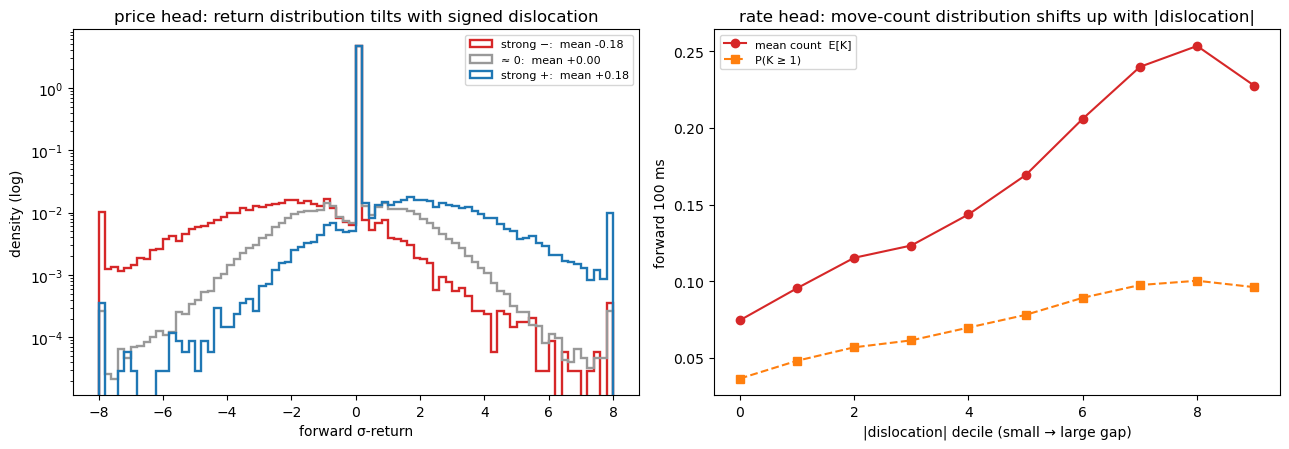

In [7]:
rep_ex = OTHERS[0]                                                              # one exchange shown to illustrate the shape; the model still uses every exchange
signed = price_dislocation(spreads[rep_ex], FAST[price_member[rep_ex][0]], SLOW[price_member[rep_ex][1]])
absmag = np.abs(price_dislocation(spreads[rep_ex], FAST[rate_member[rep_ex][0]], SLOW[rate_member[rep_ex][1]]))
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-dislocation buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"),
          ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axA.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head: return distribution tilts with signed dislocation"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with |dislocation|
dec = np.digitize(absmag, np.nanpercentile(absmag, np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|dislocation| decile (small → large gap)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count distribution shifts up with |dislocation|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the way the two heads
need — not just a single summary number. **Price head (left):** the forward-return distribution
shifts bodily with the *signed* feature — a negative mean return for the strong-negative group,
positive for the strong-positive group, with the flat ≈0 group between — so the sign genuinely
carries direction. **Rate head (right):** both the mean move-count `E[K]` and `P(K ≥ 1)` climb
monotonically from the smallest to the largest |dislocation| decile — a big gap really does
precede more catch-up moves. So both heads have something to learn here, in the directions §1
predicted.

## 8. Input shaping for the network

This is a *different* step from §2. There we divided out volatility (the "regime division") so
the feature means the same thing in any market. Here we reshape the feature for the neural
network's input — roughly centred, unit-scale, no wild outliers.

Pick the **lightest** transform that does the job. Plot the feature (left) and compare a few
candidates by how close to a clean bell curve they make it (right — points on the diagonal are
perfectly normal). A symmetric, mild feature only needs a simple rescale (z-score: subtract
the mean, divide by the standard deviation); a heavily skewed or fat-tailed one needs more
(e.g. a rank-to-normal map: sort the values and reassign them onto a bell curve). The plot
makes the choice for you.

feature: std=1.5  skew=-0.00  excess_kurt=0.7  (0 = normal)
  z-score            excess_kurt=   0.7   max|·|=21.6
  robust + clip ±4   excess_kurt=   0.2   max|·|=4.0
  arcsinh(robust)    excess_kurt=  -0.8   max|·|=3.8
  rank-Gaussian      excess_kurt=  -0.0   max|·|=5.0


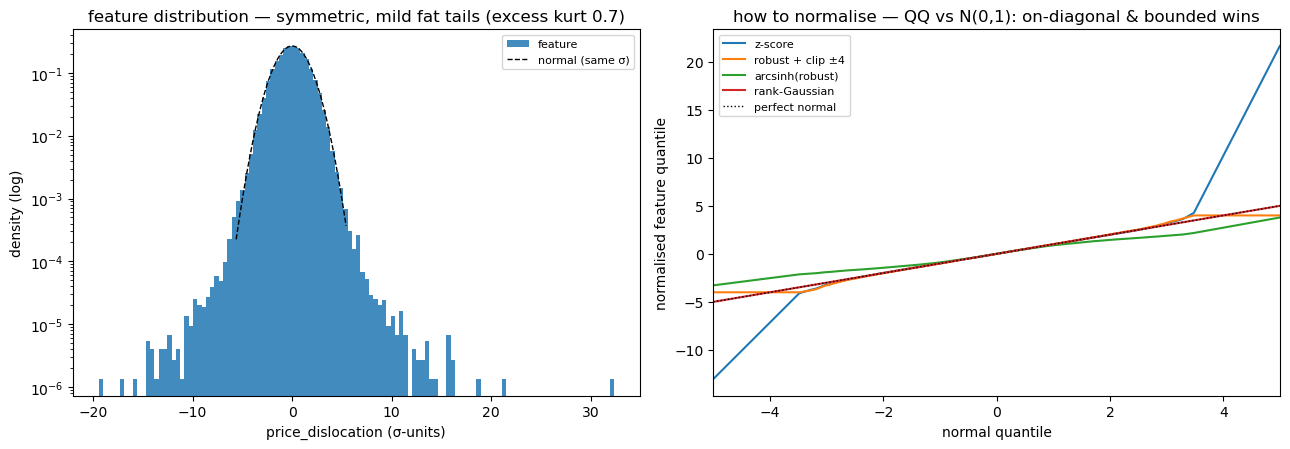

In [8]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_ex = OTHERS[0]                                                              # one exchange shown to illustrate the shape (same construction for every exchange)
f = price_dislocation(spreads[rep_ex], FAST[price_member[rep_ex][0]], SLOW[price_member[rep_ex][1]]); f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)); rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / f.std(),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature: std={f.std():.1f}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature")
xg = np.linspace(np.percentile(f, 0.05), np.percentile(f, 99.95), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("price_dislocation (σ-units)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution — symmetric, mild fat tails (excess kurt {kurtosis(f):.1f})")
axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** For this feature the printout settles it: it's already near-symmetric (skew ≈ 0)
with only mild fat tails — *because* it's divided by `σ_ev` — so a plain rescale (z-score) keeps
the excess kurtosis low and is enough, or a clipped version if you want bounded inputs. The
heavier transforms (arcsinh, rank-Gaussian) flatten the tails further but would just throw
information away here. A skewed or fat-tailed feature would push you the other way; the QQ-plot
tells you which.

**Still to run** (same machinery): the leak check *inside* volatility buckets; whether the
feature adds over features we already have; whether the signal is steady day-to-day; and
whether it survives out-of-sample across a market-regime change.

## 9. When is per-exchange worth it? (for poolable features)

`price_dislocation` is a *gap between* exchanges, so it has to be per-exchange — there's no
single "pooled" version. But many features (trade-flow, order-flow imbalance, queue
imbalance) *can* be pooled into one number, and then you face a real choice: keep them
**per-exchange**, collapse to **one exchange**, or **pool** them all? The answer depends on
the time-scale, so sweep it and compare the three.

> **The table below is an illustrative example for a poolable trade-flow feature — it is NOT
> computed for `price_dislocation`** (whose real per-exchange numbers are the heat-maps in §6).
> It just shows the typical pattern, predicting byb's next 100 ms.

| time-scale | pooled | best single | per-exchange | what it means |
|---|---|---|---|---|
| ≤ 50 ms | 0.22 | **0.23** | 0.22 | one exchange is enough — splitting just adds noise |
| ~500 ms | 0.11 | 0.12 | **0.16** | keep per-exchange — exchanges genuinely differ here |
| ≥ 2.5 s | 0.08 | 0.08 | 0.09 | exchanges agree — any one will do |

So: at the shortest scales the signal lives in one exchange; in a **middle band** the
exchanges genuinely differ (who's leading whom) and keeping them separate pays off; at long
scales they all converge. Pooling everything is never the best — it blurs away exactly that
middle-band structure. (Longer prediction horizons push the useful band wider, so in general
sweep the horizon too.)

## 10. The verdict, and what it takes to ship

**Keep it — feed the *signed* feature to both heads, all exchanges, at a couple of time-scales
each:**
- **Price head (direction):** a fast average over a slow one — how much to smooth the fast leg
  is exchange-dependent (here bin's price head took a lightly-smoothed fast=10, okx's the raw
  fast=1).
- **Rate head (intensity):** a sharp, unsmoothed time-scale (fast leg minus a fast slow-leg).
  The *magnitude* of the gap is what predicts a burst of moves, but you still feed the
  **signed** feature and let the rate head recover that — and learn how exchanges' gaps
  cancel or reinforce. (Feeding pre-`|·|` per exchange would block that.)

Feed **every exchange's** signed feature in and let the model lean on whichever is leading at
the moment; don't collapse to a single "leader." The feature is divided by the volatility
yardstick; the move-count it predicts is divided by the rate yardstick.

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, matching this analysis version
- [ ] the oracle (§4) and tests, passing
- [ ] the gate results recorded (with any failures justified)
- [ ] the chosen heads and time-scales written down, with the yardstick windows
- [ ] the data quirks handled (bad zero-price prints; the right price source per exchange)